# **Adding Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Datasets Available in Scikit Learn

In [2]:
from sklearn import datasets
print(datasets.__all__)

['clear_data_home', 'dump_svmlight_file', 'fetch_20newsgroups', 'fetch_20newsgroups_vectorized', 'fetch_california_housing', 'fetch_covtype', 'fetch_file', 'fetch_kddcup99', 'fetch_lfw_pairs', 'fetch_lfw_people', 'fetch_olivetti_faces', 'fetch_openml', 'fetch_rcv1', 'fetch_species_distributions', 'get_data_home', 'load_breast_cancer', 'load_diabetes', 'load_digits', 'load_files', 'load_iris', 'load_linnerud', 'load_sample_image', 'load_sample_images', 'load_svmlight_file', 'load_svmlight_files', 'load_wine', 'make_biclusters', 'make_blobs', 'make_checkerboard', 'make_circles', 'make_classification', 'make_friedman1', 'make_friedman2', 'make_friedman3', 'make_gaussian_quantiles', 'make_hastie_10_2', 'make_low_rank_matrix', 'make_moons', 'make_multilabel_classification', 'make_regression', 'make_s_curve', 'make_sparse_coded_signal', 'make_sparse_spd_matrix', 'make_sparse_uncorrelated', 'make_spd_matrix', 'make_swiss_roll']


# **Loading Dataset**

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


# Load the Iris dataset
iris = load_iris()

# Create a DataFrame from the dataset
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Basic Parameters Checking

In [4]:
# Adding Target Variable to Data

data["target"] = iris.target
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
# Checking for Missing Values
data.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

---
# **Statistical Analysis**

In [ ]:
# Dataset Size (Rows, Columns)
data.shape

In [ ]:
# Dataset Column Names
data.columns

In [5]:
# Display summary statistics for numerical columns
data.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


---
# **Visual Analysis**


### **Univariate Analysis**

## Histogram Data Distibution 

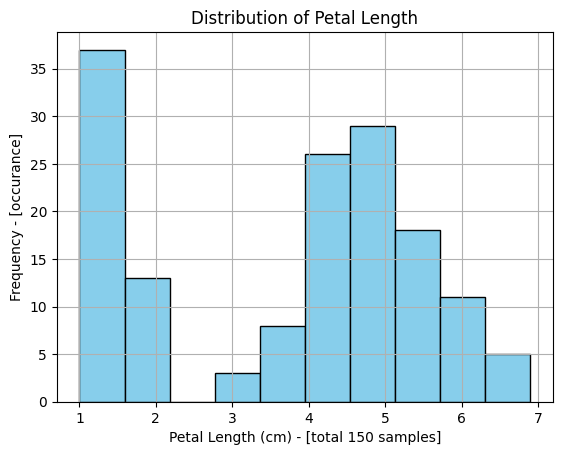

In [10]:
plt.hist(data["petal length (cm)"], bins=10,  color="skyblue", edgecolor="black",)
plt.xlabel("Petal Length (cm) - [total 150 samples]")
plt.ylabel("Frequency - [occurance]")
plt.title("Distribution of Petal Length")
plt.grid()
plt.show()

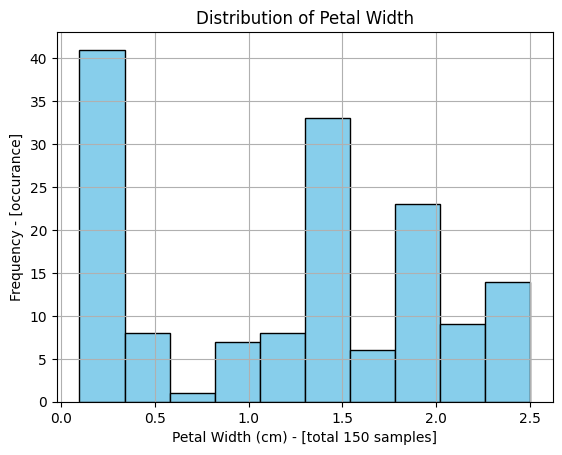

In [11]:
plt.hist(data["petal width (cm)"], bins=10,  color="skyblue", edgecolor="black",)
plt.xlabel("Petal Width (cm) - [total 150 samples]")
plt.ylabel("Frequency - [occurance]")
plt.title("Distribution of Petal Width")
plt.grid()
plt.show()

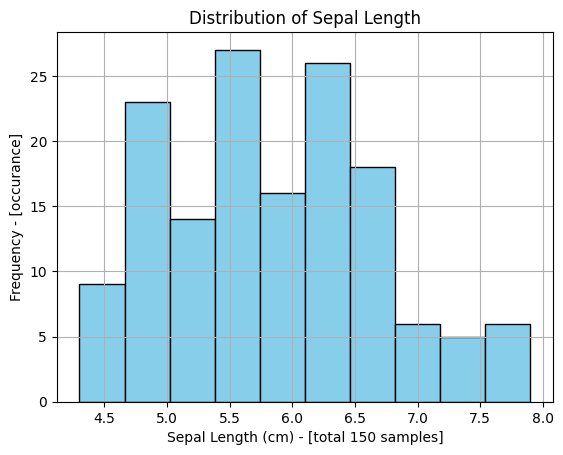

In [12]:
plt.hist(data["sepal length (cm)"], bins=10,  color="skyblue", edgecolor="black",)
plt.xlabel("Sepal Length (cm) - [total 150 samples]")
plt.ylabel("Frequency - [occurance]")
plt.title("Distribution of Sepal Length")
plt.grid()
plt.show()

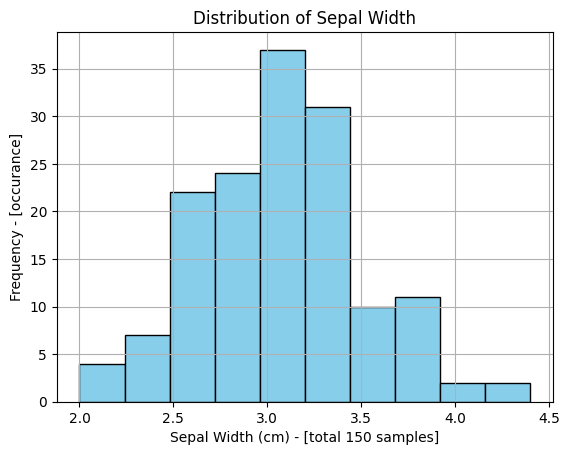

In [13]:
plt.hist(data["sepal width (cm)"], bins=10,  color="skyblue", edgecolor="black",)
plt.xlabel("Sepal Width (cm) - [total 150 samples]")
plt.ylabel("Frequency - [occurance]")
plt.title("Distribution of Sepal Width")
plt.grid()
plt.show()

Overall due to multple (3) classes under each feature the Data distirbution seems multimodal in terms of petal length and petal width but symetric or little skewed in terms of sepal lenght & width - which turns to be fine because none of the graphs showed any outlier visually here, but we will see in the next graphs to detect outliers

## Box Plot (Outliers and Spread Detection)

Skewness of Petal Length: -0.27488417975101276


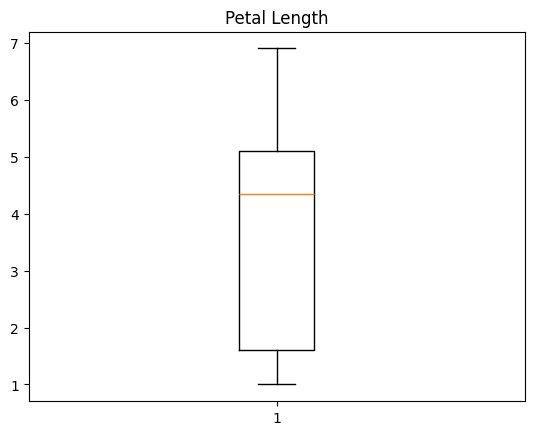

In [20]:
plt.boxplot(data["petal length (cm)"])
# plt.boxplot(data["petal length (cm)"], vert=False)
plt.title("Petal Length")

skewness = data["petal length (cm)"].skew()
print(f"Skewness of Petal Length: {skewness}")

Skewness of Petal Width: -0.10296674764898116


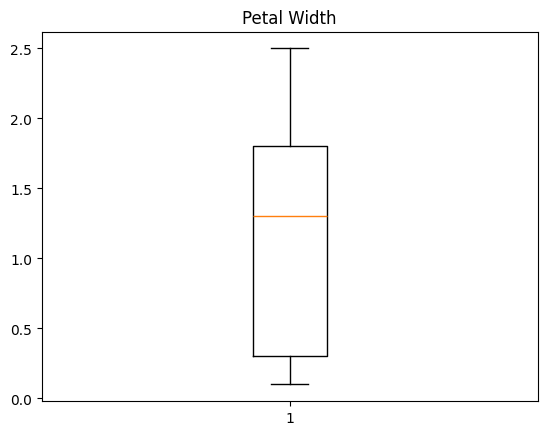

In [21]:
plt.boxplot(data["petal width (cm)"])
plt.title("Petal Width")

skewness = data["petal width (cm)"].skew()
print(f"Skewness of Petal Width: {skewness}")

Skewness of Sepal Length: 0.3149109566369728


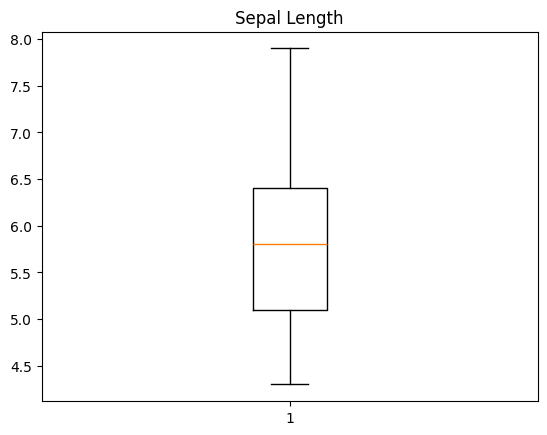

In [22]:
plt.boxplot(data["sepal length (cm)"])
plt.title("Sepal Length")

skewness = data["sepal length (cm)"].skew()
print(f"Skewness of Sepal Length: {skewness}")

Skewness of Sepal Width: 0.31896566471359966


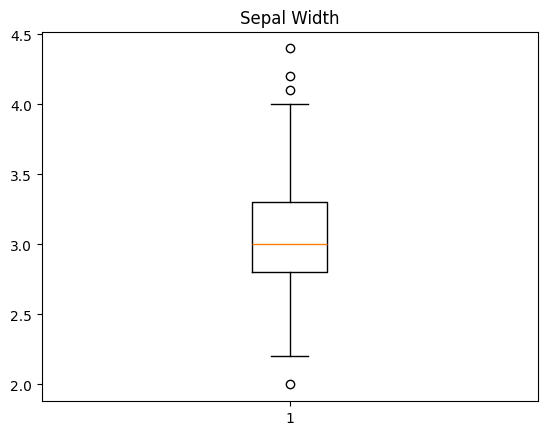

In [23]:
plt.boxplot(data["sepal width (cm)"])
plt.title("Sepal Width")

skewness = data["sepal width (cm)"].skew()
print(f"Skewness of Sepal Width: {skewness}")

From these Box Graph , it is clear that there is skewness but little so it's bearable because skew values lies in between the -0.5 and 0.5 so data is in the safe zone - but at Sepal Width we can clearly see there exist some outliers we need to handle them before training.

---
### **Bi-variate Analysis**

## Scatter Plot

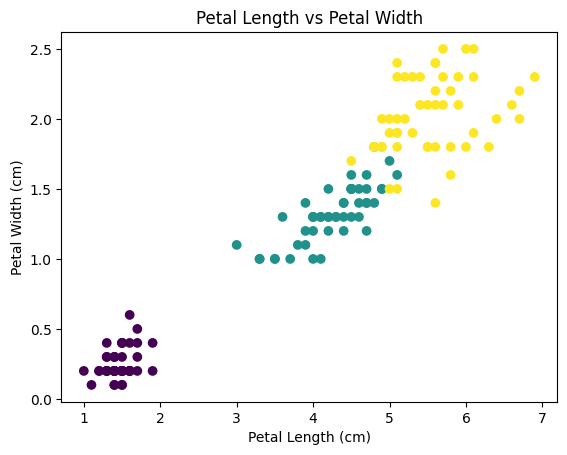

In [ ]:
plt.scatter(data["petal length (cm)"], data["petal width (cm)"], c=data["target"])
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.show()

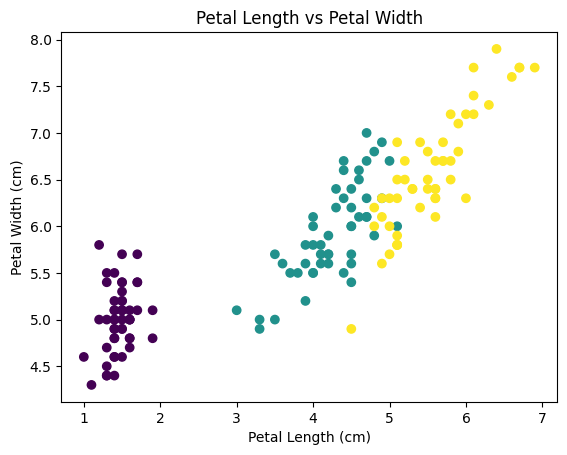

In [ ]:
plt.scatter(data["petal length (cm)"], data["sepal length (cm)"], c=data["target"])
plt.xlabel("Petal Length (cm)")
plt.ylabel("Sepal Length (cm)")
plt.title("Petal Length vs Sepal Length")
plt.show()

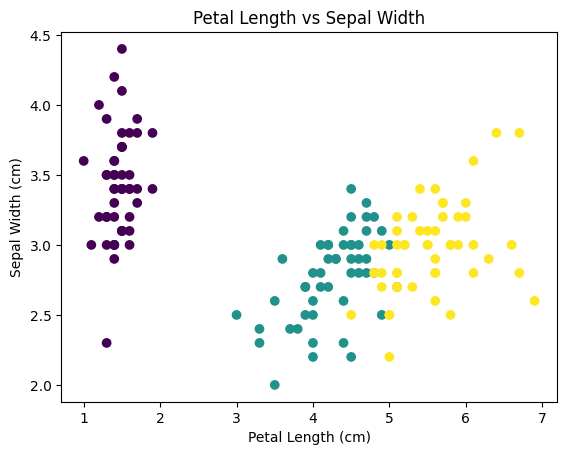

In [25]:
plt.scatter(data["petal length (cm)"], data["sepal width (cm)"], c=data["target"])
plt.xlabel("Petal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Petal Length vs Sepal Width")
plt.show()

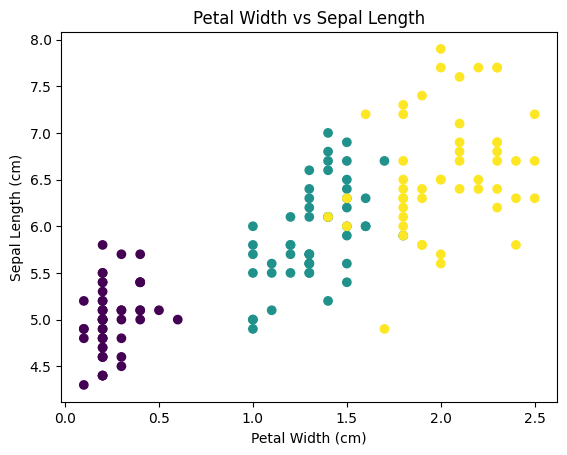

In [27]:
plt.scatter(data["petal width (cm)"], data["sepal length (cm)"], c=data["target"])
plt.xlabel("Petal Width (cm)")
plt.ylabel("Sepal Length (cm)")
plt.title("Petal Width vs Sepal Length")
plt.show()

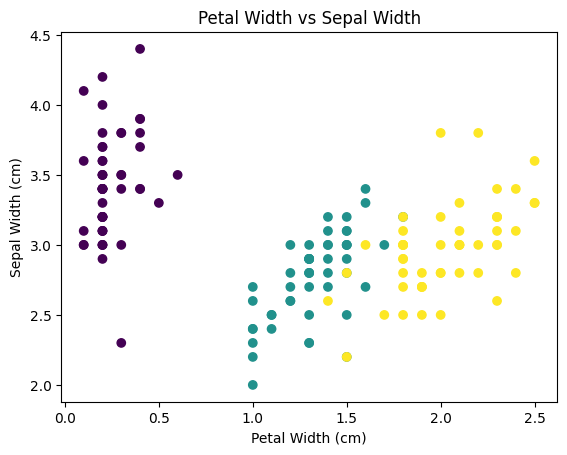

In [28]:
plt.scatter(data["petal width (cm)"], data["sepal width (cm)"], c=data["target"])
plt.xlabel("Petal Width (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Petal Width vs Sepal Width")
plt.show()

Instead of creating each graph individually we use Pairplot to analyze all at once...

---
# Multi-variate Analysis

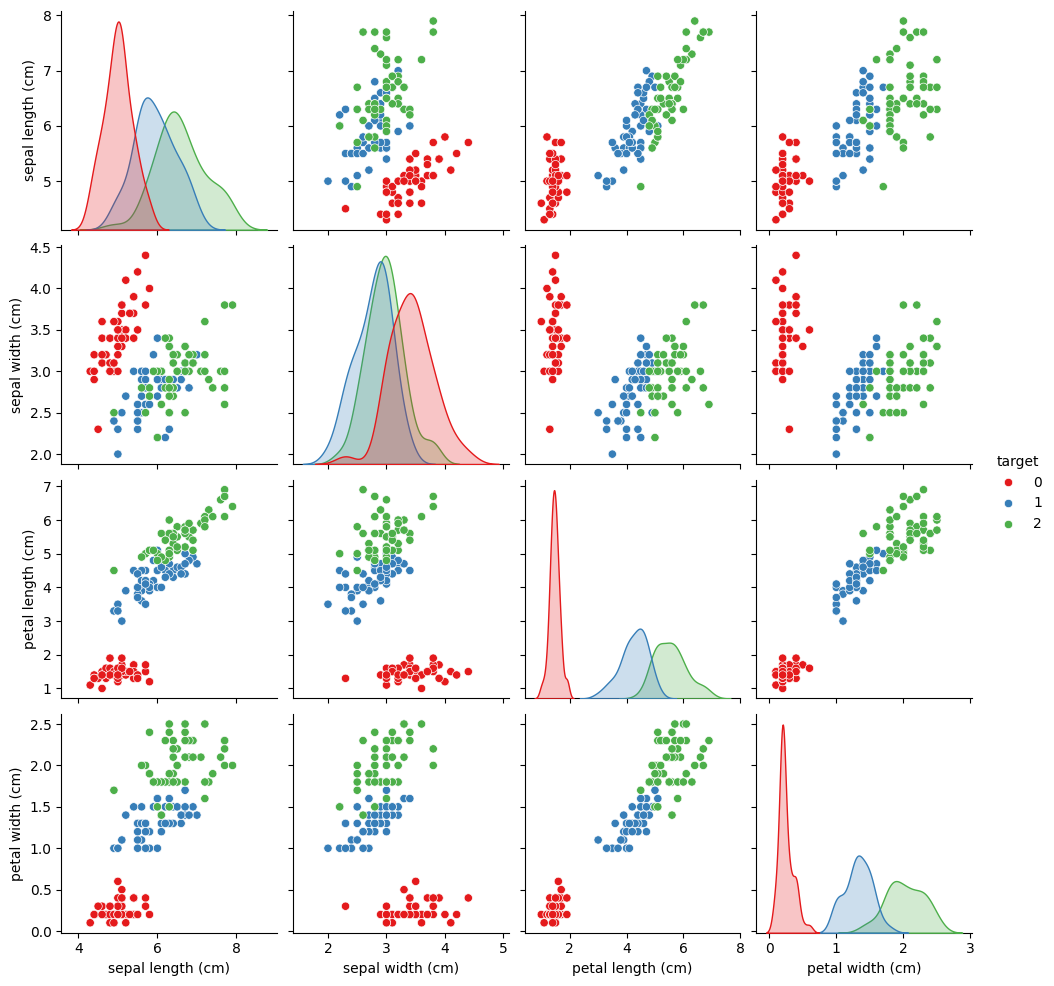

In [26]:
sns.pairplot(data, hue="target", palette="Set1")
# sns.pairplot(data, hue="target", markers=["o", "s", "D"], palette="Set1")

From this Pair Plot, we can clearly see that the class Setosa (0) is well separated from the other two classes. The confusion is being created between class 1 and class 2 due to overlapping